# SSSUMO: Real-Time Semi-Supervised Submovement Decomposition

**SSSUMO** is a neural network-based method for decomposing continuous movement signals into constituent submovements. The approach is *semi-supervised*: it learns from both synthetic data with known ground-truth decompositions and real human motion data without labels.

### What does SSSUMO do?

Given a tangential velocity signal, SSSUMO detects:
- **Onset times** of individual submovements
- **Amplitude** (also known as displacement, AUC) of each submovement
- **Duration** of each submovement

These parameters allow reconstructing the original signal as a superposition of bell-shaped min-jerk velocity primitives, providing an interpretable decomposition of complex movements.

### About this notebook

This notebook demonstrates how to **run inference** with pre-trained SSSUMO models on both synthetic and organic human motion datasets and **visualize** the decomposition process. For details on how to **use your own data** with SSSUMO, see the discussion at the end of the notebook.

You can run this notebook directly in Google Colab — it will automatically clone the repository, install dependencies, and download the pre-trained model weights.

# Setting things up

### Clone the repo (if Colab)

In [ ]:
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


if IN_COLAB:
    %cd /content/
    if not os.path.exists("sssumo"):
        !git clone https://github.com/dolphin-in-a-coma/sssumo.git
        print("Repository cloned successfully.")
    else:
        print("Repository already exists.")

    %cd sssumo

    !pip install .

/content
Cloning into 'sssumo'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (104/104), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 104 (delta 49), reused 82 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (104/104), 13.28 MiB | 28.80 MiB/s, done.
Resolving deltas: 100% (49/49), done.
Repository cloned successfully.
/content/sssumo
Processing /content/sssumo
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.1 MB/s eta 0:00:00
  Created wheel for sssumo: filename=sssumo-0.1.0-py3-none-any.whl size=69877 sha256=b7fcbd62313e9a701e07614ff2524d8392b18bb2a153ab523378cd4624dd2cf4
  Stored in directory: /tmp/pip-ephem-wheel-cache-be6cmman/wheels/51/f2/5d/1e636e645626fe7e658d02775729b7c4c80e4adc06aa26df01
Successfully built sssumo


### Download the data (if Colab)

In [ ]:
if IN_COLAB:
    !mkdir -p data
    !curl -L "https://datacloud.helsinki.fi/public.php/dav/files/bE7SP7xCrSyApeC/?accept=zip" -o data/sssumo_data.zip
    !unzip -o data/sssumo_data.zip -d data/
    !mv data/sssumo_data/* data/
    !rm -r data/sssumo_data data/sssumo_data.zip

# NOTE: can work outside of Colab, but you'll need to ensure the data path is correct


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1815M    0 1815M    0     0  28.1M      0 --:--:--  0:01:04 --:--:-- 30.1M
Archive:  data/sssumo_data.zip
   creating: data/sssumo_data/
 extracting: data/sssumo_data/crank_tangential_velocity_data.csv  
 extracting: data/sssumo_data/Fitts_tangential_velocity_data.csv  
 extracting: data/sssumo_data/object_moving_tangential_velocity_data.csv  
 extracting: data/sssumo_data/pointing_tangential_velocity_data.csv  
 extracting: data/sssumo_data/steering_tangential_velocity_data.csv  
 extracting: data/sssumo_data/tablet_writing_tangential_velocity_data.csv  
 extracting: data/sssumo_data/whacamole_tangential_velocity_data.csv  


### Specify model and data paths



In [ ]:
fine_tuned_model = True

if IN_COLAB:
    root_dir = '/content/sssumo/'
else:
    root_dir = '../' # NOTE: assuming you're running this from ./notebooks/

nn_config_dir = os.path.join(root_dir, 'configs')
nn_checkpoint_dir = os.path.join(root_dir, 'checkpoints')
datasets_dir = os.path.join(root_dir, 'data')

if fine_tuned_model:
    nn_config_name = 'config-0425-tune_ModGauss_wo_writing.yaml'
    nn_checkpoint_number = 9
else:
    nn_config_name = 'config-0423-ModGaussian_ampl.yaml'
    nn_checkpoint_number = 24

nn_checkpoint_name = f'{nn_config_name.split(".")[0]}_{nn_checkpoint_number}.pth'
nn_config_path = os.path.join(nn_config_dir, nn_config_name)
nn_checkpoint_path = os.path.join(nn_checkpoint_dir, nn_checkpoint_name)

dataset2path = {
    'steering': os.path.join(datasets_dir, 'steering_tangential_velocity_data.csv'),
    'crank': os.path.join(datasets_dir, 'crank_tangential_velocity_data.csv'),
    'Fitts': os.path.join(datasets_dir, 'Fitts_tangential_velocity_data.csv'),
    'whacamole': os.path.join(datasets_dir, 'whacamole_tangential_velocity_data.csv'),
    'object_moving': os.path.join(datasets_dir, 'object_moving_tangential_velocity_data.csv'),
    'pointing': os.path.join(datasets_dir, 'pointing_tangential_velocity_data.csv'),
    'tablet_writing': os.path.join(datasets_dir, 'tablet_writing_tangential_velocity_data.csv'),
}

### Imports

In [ ]:
from sssumo.data import SyntheticDataset, OrganicDataset, CombinedSyntheticDataset, ConstantDistribution
from sssumo.models import TDNNDetector, STEContinuousReconstructor, STEBinarizer
from sssumo.utils import onset_prediction_metrics_on_masks, Config, evaluate_on_organic_data, evaluate_on_synthetic_data, \
    calculate_reconstruction_metrics, calculate_supervised_metrics, \
    evaluate_organic_trials_for_bootstrap, hierarchical_bootstrap_metrics

# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import numpy as np
import torch
import math


from ipywidgets import IntRangeSlider, IntSlider, IntText, Dropdown

### Visualization helpers

In [ ]:
def to_numpy(tensor):
    if hasattr(tensor, 'detach'):
        return tensor.detach().cpu().numpy()
    return tensor

# Shared Styles
STYLE_NOISY = dict(color='black', width=1)
STYLE_CLEAN = dict(color='blue', width=2)
STYLE_RECON = dict(color='red', dash='dash', width=2)
MARKER_TRUE = dict(color='blue', symbol='circle', size=8)
MARKER_PRED = dict(color='red', symbol='circle-open', size=8, line_width=2)

def plot_submovement_decomposition_plotly(x_noisy, x_clean, x_reconstructed, y_true, y_pred, binarized_mask_pred, true_primitives, pred_primitives, sr=60, include=(True, True, True, True, True)):
    show_signals, show_submovs, show_mask, show_ampl, show_dur = include

    if not any(include):
        print("No plots requested.")
        return

    # Prepare data
    T = x_noisy.shape[-1]
    time_axis = np.arange(T) / sr

    # Create subplots
    subplot_titles = []
    if show_signals: subplot_titles.append("Signal Reconstruction")
    if show_submovs: subplot_titles.append("Submovements")
    if show_mask: subplot_titles.append("Detection / Mask")
    if show_ampl: subplot_titles.append("Amplitude")
    if show_dur: subplot_titles.append("Duration")

    rows = len(subplot_titles)
    fig = make_subplots(
        rows=rows, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.05,
        subplot_titles=subplot_titles
    )

    current_row = 1

    # 1. Signals
    if show_signals:
        fig.add_trace(go.Scatter(x=time_axis, y=to_numpy(x_noisy[0, 0]), name="Noisy Input", line=STYLE_NOISY, legendgroup="signals"), row=current_row, col=1)
        fig.add_trace(go.Scatter(x=time_axis, y=to_numpy(x_clean[0, 0]), name="Clean Target", line=STYLE_CLEAN, legendgroup="signals"), row=current_row, col=1)
        fig.add_trace(go.Scatter(x=time_axis, y=to_numpy(x_reconstructed[0, 0]), name="Reconstructed", line=STYLE_RECON, legendgroup="signals"), row=current_row, col=1)
        current_row += 1

    # 2. Submovements
    if show_submovs:
        # True Submovements
        true_submovement_onsets = torch.where(y_true[0,0])[0]
        for i, submovement_onset in enumerate(true_submovement_onsets):
            submovement_onset = submovement_onset.item()
            duration_value = y_true[0, 2, submovement_onset].item()
            if true_primitives is not None:
                primitive_slice = true_primitives[0, submovement_onset][:math.ceil(duration_value)]
                velocity_profile = torch.cat([torch.zeros(1).to(primitive_slice.device), primitive_slice])
                velocity_profile_time_points = (torch.arange(0, duration_value + 1, 1) + submovement_onset) / sr

                fig.add_trace(go.Scatter(
                    x=velocity_profile_time_points.cpu().numpy(),
                    y=velocity_profile.detach().cpu().numpy(),
                    mode='lines',
                    line=dict(color='blue', width=2),
                    showlegend=(i==0),
                    name="True Submovement",
                    legendgroup="submovs"
                ), row=current_row, col=1)

        # Predicted Submovements
        predicted_submovement_onsets = torch.where(binarized_mask_pred[0])[0]
        duration_pred_tensor = y_pred[:, 2, :]
        for i, submovement_onset in enumerate(predicted_submovement_onsets):
            submovement_onset = submovement_onset.item()
            duration_value = duration_pred_tensor[0, submovement_onset].item()
            if pred_primitives is not None:
                primitive_slice = pred_primitives[0, submovement_onset][:math.ceil(duration_value)]
                velocity_profile = torch.cat([torch.zeros(1).to(primitive_slice.device), primitive_slice])
                velocity_profile_time_points = (torch.arange(0, duration_value + 1, 1) + submovement_onset - 0.5) / sr

                fig.add_trace(go.Scatter(
                    x=velocity_profile_time_points.cpu().numpy(),
                    y=velocity_profile.detach().cpu().numpy(),
                    mode='lines',
                    line=dict(color='red', dash='dash', width=2),
                    showlegend=(i==0),
                    name="Pred Submovement",
                    legendgroup="submovs"
                ), row=current_row, col=1)
        current_row += 1

    # Prepare indices for marker plots
    if show_mask or show_ampl or show_dur:
        true_mask_np = to_numpy(y_true[0, 0])
        true_indices = np.where(true_mask_np == 1)[0]
        pred_mask_np = to_numpy(binarized_mask_pred[0])
        pred_indices = np.where(pred_mask_np == 1)[0]

    # 3. Mask
    if show_mask:
        fig.add_trace(go.Scatter(x=time_axis, y=to_numpy(y_pred[0, 0]), name="Pred Mask", line=dict(color='red', width=2), legendgroup="mask"), row=current_row, col=1)
        fig.add_trace(go.Scatter(x=time_axis[true_indices], y=to_numpy(y_true[0, 0])[true_indices],
                                  name="True Mask", mode='markers', marker=MARKER_TRUE, legendgroup="mask"), row=current_row, col=1)
        fig.add_trace(go.Scatter(x=time_axis[pred_indices], y=to_numpy(y_pred[0, 0])[pred_indices],
                                  name="Pred Mask (Det)", mode='markers', marker=MARKER_PRED, legendgroup="mask"), row=current_row, col=1)
        current_row += 1

    # 4. Amplitude
    if show_ampl:
        fig.add_trace(go.Scatter(x=time_axis, y=to_numpy(y_pred[0, 1]), name="Pred Amplitude", line=dict(color='red', width=2), legendgroup="ampl"), row=current_row, col=1)
        fig.add_trace(go.Scatter(x=time_axis[true_indices], y=to_numpy(y_true[0, 1])[true_indices],
                                  name="True Amplitude", mode='markers', marker=MARKER_TRUE, legendgroup="ampl"), row=current_row, col=1)
        fig.add_trace(go.Scatter(x=time_axis[pred_indices], y=to_numpy(y_pred[0, 1])[pred_indices],
                                  name="Pred Amplitude (Det)", mode='markers', marker=MARKER_PRED, legendgroup="ampl"), row=current_row, col=1)
        current_row += 1

    # 5. Duration
    if show_dur:
        fig.add_trace(go.Scatter(x=time_axis, y=to_numpy(y_pred[0, 2]), name="Pred Duration", line=dict(color='red', width=2), legendgroup="dur"), row=current_row, col=1)
        fig.add_trace(go.Scatter(x=time_axis[true_indices], y=to_numpy(y_true[0, 2])[true_indices],
                                  name="True Duration", mode='markers', marker=MARKER_TRUE, legendgroup="dur"), row=current_row, col=1)
        fig.add_trace(go.Scatter(x=time_axis[pred_indices], y=to_numpy(y_pred[0, 2])[pred_indices],
                                  name="Pred Duration (Det)", mode='markers', marker=MARKER_PRED, legendgroup="dur"), row=current_row, col=1)
        current_row += 1

    fig.update_layout(title="Comprehensive Analysis", height=250 * max(1, rows), template="plotly_white")
    if rows > 0:
        fig.update_xaxes(title_text="Time (s)", row=rows, col=1)
    fig.show()

def plot_submovement_decomposition_matplotlib(x_noisy, x_clean, x_reconstructed, y_true, y_pred, binarized_mask_pred, true_primitives, pred_primitives, sr=60, include=(True, True, True, True, True)):
    show_signals, show_submovs, show_mask, show_ampl, show_dur = include


    if not any(include):
        print("No plots requested.")
        return

    num_rows = sum(include)
    fig, axes = plt.subplots(num_rows, 1, figsize=(10, 2 * num_rows), sharex=True, dpi=200)
    if num_rows == 1:
        axes = [axes]

    current_ax_idx = 0
    T = x_noisy.shape[-1]
    time_axis = np.arange(T) / sr

    # 1. Signals
    if show_signals:
        ax = axes[current_ax_idx]
        ax.plot(time_axis, to_numpy(x_noisy[0, 0]), label="Noisy Input", color='black', linewidth=1)
        ax.plot(time_axis, to_numpy(x_clean[0, 0]), label="Clean Target", color='blue', linewidth=2)
        ax.plot(time_axis, to_numpy(x_reconstructed[0, 0]), label="Reconstructed", color='red', linestyle='--', linewidth=2)
        ax.set_title("Noisy Signal, Clean Ground-Truth, and Reconstructed Signals")
        ax.legend(loc='upper right')
        ax.grid()
        current_ax_idx += 1

    # 2. Submovements
    if show_submovs:
        ax = axes[current_ax_idx]
        # True Submovements
        true_submovement_onsets = torch.where(y_true[0, 0])[0]
        for i, submovement_onset in enumerate(true_submovement_onsets):
            submovement_onset = submovement_onset.item()
            duration_value = y_true[0, 2, submovement_onset].item()
            if true_primitives is not None:
                primitive_slice = true_primitives[0, submovement_onset][:math.ceil(duration_value)]
                velocity_profile = torch.cat([torch.zeros(1).to(primitive_slice.device), primitive_slice])
                # Use len(velocity_profile) to ensure dimensions match
                velocity_profile_time_points = (torch.arange(0, len(velocity_profile), 1) + submovement_onset) / sr
                ax.plot(velocity_profile_time_points.cpu().numpy(), velocity_profile.detach().cpu().numpy(), color='blue', label="True Submovement" if i == 0 else "")

        # Predicted Submovements
        predicted_submovement_onsets = torch.where(binarized_mask_pred[0])[0]
        duration_pred_tensor = y_pred[:, 2, :]
        for i, submovement_onset in enumerate(predicted_submovement_onsets):
            submovement_onset = submovement_onset.item()
            duration_value = duration_pred_tensor[0, submovement_onset].item()
            if pred_primitives is not None:
                primitive_slice = pred_primitives[0, submovement_onset][:math.ceil(duration_value)]
                velocity_profile = torch.cat([torch.zeros(1).to(primitive_slice.device), primitive_slice])
                # Use len(velocity_profile) to ensure dimensions match
                velocity_profile_time_points = (torch.arange(0, len(velocity_profile), 1) + submovement_onset - 0.5) / sr
                ax.plot(velocity_profile_time_points.cpu().numpy(), velocity_profile.detach().cpu().numpy(), color='red', linestyle='--', label="Pred Submovement" if i == 0 else "")

        ax.set_title("Ground-truth and Reconstructed Submovements Decomposition")
        ax.legend(loc='upper right')
        ax.grid()
        current_ax_idx += 1

    # Prepare indices for marker plots
    if show_mask or show_ampl or show_dur:
        true_mask_np = to_numpy(y_true[0, 0])
        true_indices = np.where(true_mask_np == 1)[0]
        pred_mask_np = to_numpy(binarized_mask_pred[0])
        pred_indices = np.where(pred_mask_np == 1)[0]

    # 3. Mask
    if show_mask:
        ax = axes[current_ax_idx]
        ax.plot(time_axis, to_numpy(y_pred[0, 0]), color='red', label="Predicted Onset Probability")
        ax.scatter(time_axis[true_indices], to_numpy(y_true[0, 0])[true_indices], color='blue', marker='o', s=50, label="True Onsets")
        ax.scatter(time_axis[pred_indices], to_numpy(y_pred[0, 0])[pred_indices], color='red', marker='o', facecolors='none', s=50, label="Predicted Onsets [Threshold at 0.5]")
        ax.set_title("Ground-Truth Onsets and Onset Detection Signal")
        ax.legend(loc='upper right')
        ax.grid()
        current_ax_idx += 1

    # 4. Amplitude
    if show_ampl:
        ax = axes[current_ax_idx]
        ax.plot(time_axis, to_numpy(y_pred[0, 1]), color='red', label="Predicted Amplitude Signal")
        ax.scatter(time_axis[true_indices], to_numpy(y_true[0, 1])[true_indices], color='blue', marker='o', s=50, label="True Amplitude")
        ax.scatter(time_axis[pred_indices], to_numpy(y_pred[0, 1])[pred_indices], color='red', marker='o', facecolors='none', s=50, label="Predicted Amplitude for Detected Submovements")
        ax.set_title("Ground-Truth and Predicted Amplitude")
        ax.legend(loc='upper right')
        ax.grid()
        current_ax_idx += 1

    # 5. Duration
    if show_dur:
        ax = axes[current_ax_idx]
        ax.plot(time_axis, to_numpy(y_pred[0, 2]), color='red', label="Predicted Duration Signal")
        ax.scatter(time_axis[true_indices], to_numpy(y_true[0, 2])[true_indices], color='blue', marker='o', s=50, label="True Duration")
        ax.scatter(time_axis[pred_indices], to_numpy(y_pred[0, 2])[pred_indices], color='red', marker='o', facecolors='none', s=50, label="Predicted Duration for Detected Submovements")
        ax.set_title("Ground-Truth and Predicted Duration")
        ax.legend(loc='upper right')
        ax.grid()
        current_ax_idx += 1

    plt.xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

### Loading model

In [ ]:
config = Config(nn_config_path, root_dir=root_dir)

config.start_with_weights = nn_checkpoint_path

print(config.experiment_name)

model = TDNNDetector(
        batchnorm=config.batchnorm,
        dilations=config.dilations,
        channels=config.channels,
        kernel_sizes=config.kernel_sizes,
        num_layers=config.num_layers,
        dropout_rate=config.dropout_rate,
    ).to(config.device, config.dtype)

model.eval()


basic_dataset = SyntheticDataset(**config.get_dataset_parameters())

reconstructor = basic_dataset.reconstruction_model

# train_noise_condition = config.stat_snr_distribution

model.load_state_dict(torch.load(config.start_with_weights, map_location=config.device))

0425-tune_ModGauss_wo_writing


/usr/local/lib/python3.12/dist-packages/torch/distributions/distribution.py:62: UserWarning: <class 'sssumo.data.ModulatedGaussian'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


<All keys matched successfully>

# Demonstrating inference on synthetic data



### Synthetic data parameters


**Key parameters affecting the generation:**
- config.refractory_distribution
- config.seed
- config.snr_distribution


#### seed
Random seed for reproducibility


> The following two parameters control the main level of difficulty


#### refractory_distribution, other names: onset-to-onset/delay distribution

- Can be a single value, a tuple of two values, or one of the available distributions (check code)

The most common format is a tuple of [MIN_REFRACTORY_PERIOD, MAX_REFRACTORY_PERIOD]. Then refractory periods for submovements will be sampled uniformly from the range.
This parameter is the main one that controls the level of overlap of submovements. When the values are closer to 0, submovements will be more overlapped; with values above 1, there will be no overlap.
- Units: refractory period, relative to the previous submovement duration. Refractory period is calculated from the onset time of the first submovement to the onset time of the following submovement. In that case 0 means a second submovement starts at the same time as the first one, 0.5 - in the middle of the first one, 1 - at the moment where the first submovement ends, more than 1 - submovements don't overlap.
- Values make most sense in a range from 0 to around 2


#### snr_distribution
Defines how much artificial noise is applied to the signal. Units are SNR. Values from 10 to 50 were used for training. 50 - low amount of noise, 20 - significant noise, 10 - extreme noise.
- Can be a single value, a tuple of two values, or one of the available distributions (check code)


#### Other parameters

There are some other parameters that might be useful; they are listed below with the ranges used during training.


In [ ]:
# Parameters of synthetic data generation, they can be adjusted below
config.get_dataset_parameters()
#   total_duration_distribution: [100, 500]
#   snr_distribution: [10, 50]
#   stat_snr_distribution: 20
#   duration_distribution: [5, 60]
#   amplitude_distribution: null
#   amplitude_by_duration_distribution: ['ModulatedGaussian', 0, 1, 1]
#   refractory_distribution: [0., 1.5]
#   max_submovements: null
#   refractory_mode: "percentages"
#   standardize: false
#   one_sign_chance: 0
#   hard_refractory_chance: 0
#   easy_refractory_chance: 0
#   noise_mode: "gaussian"
#   combined_dataset: false

{'total_duration_distribution': [100, 500],
 'snr_distribution': [10, 50],
 'duration_distribution': [5, 60],
 'amplitude_distribution': None,
 'amplitude_by_duration_distribution': ['ModulatedGaussian', 0, 1, 1],
 'refractory_distribution': [0.0, 1.5],
 'reconstruction_model': STEContinuousReconstructor(
   (primitive): ContinuousPrimitive()
 ),
 'max_submovements': None,
 'num_samples': 1000,
 'dtype': torch.float32,
 'device': 'cpu',
 'seed': None,
 'batch_size': 512,
 'refractory_mode': 'percentages',
 'standardize': False,
 'one_sign_chance': 0,
 'hard_refractory_chance': 0,
 'easy_refractory_chance': 0,
 'noise_mode': 'gaussian'}

### Helper for submovement decomposition on synthetic data



In [ ]:
def submovement_decomposition_on_synthetic(total_duration=600, seed=3, refractory_range=(0.0, 1.), snr=50):
    # Unpack range
    min_refractory, max_refractory = refractory_range

    if max_refractory <= min_refractory:
        max_refractory = min_refractory + 1e-5

    # Update config
    config.num_samples = 1
    config.batch_size = 1
    config.total_duration_distribution = total_duration
    config.seed = seed
    config.refractory_distribution = [min_refractory, max_refractory]
    config.snr_distribution = snr

    # Re-initialize dataset with new params
    dataset = SyntheticDataset(**config.get_dataset_parameters())

    x_noisy, x_clean, y_true = dataset[0]

    # Model inference
    y_pred = model(x_noisy).detach()

    x_reconstructed, _ = reconstructor(y_pred)

    mask_pred = y_pred[:, 0]
    auc_pred = y_pred[:, 1, :]
    duration_pred = y_pred[:, 2, :]
    auc_duration_pred = torch.stack([auc_pred, duration_pred], dim=1)
    binarized_mask_pred = reconstructor.binarizer.apply(mask_pred, True, True)

    mask_true = y_true[:, 0]
    auc_true = y_true[:, 1, :]
    duration_true = y_true[:, 2, :]
    auc_duration_true = torch.stack([auc_true, duration_true], dim=1)

    true_primitives = reconstructor.primitive(auc_duration_true)
    pred_primitives = reconstructor.primitive(auc_duration_pred)

    plot_submovement_decomposition_matplotlib(x_noisy, x_clean, x_reconstructed, y_true, y_pred, binarized_mask_pred, true_primitives, pred_primitives, sr=60, include=(True, True, True, True, True))

### Visualization of how data generation parameters affect predictions

In [ ]:
from ipywidgets import interact, IntSlider, FloatSlider, IntText, FloatRangeSlider


# Setup the interactive UI
interact(submovement_decomposition_on_synthetic,
         total_duration=IntText(value=600, description="Total Duration"),
         seed=IntText(value=3, description="Seed"),
         refractory_range=FloatRangeSlider(value=[0, 1], min=0, max=2, step=0.1, description="Refractory"),
         snr=IntSlider(min=10, max=50, step=1, value=50, description='SNR'));

interactive(children=(IntText(value=600, description='Total Duration'), IntText(value=3, description='Seed'), …

# Demonstrating inference on human motion data


### Organic data parameters

**organic_dataset_kwargs.purpose**
Can be 'train' or 'test'.
The code splits all the data by subject IDs. They are sorted and every second subject is used for training, the others are used for testing. It makes sense then to use two dataset classes if you want to process all your data and work with the existing OrganicDataset class.

**organic_dataset_kwargs.snr_distribution**
Same as for synthetic data.


### Helper for submovement decomposition on organic data


In [ ]:

# Global cache variables
_cached_dataset = None
_cached_dataset_name = None

def submovement_decomposition_on_organic(dataset_name='Fitts', sample_id=7, segment_time=(0, 900), snr=50):
    global _cached_dataset, _cached_dataset_name

    # Ensure dataset params are available
    organic_dataset_kwargs = {'snr_distribution': snr, 'noise_mode': 'gaussian', 'quadratic_mean': 1, 'low_pass_filter': np.inf, 'purpose': 'test'}

    # Load Dataset only if needed
    if _cached_dataset_name != dataset_name or _cached_dataset is None:
        print(f"Loading dataset: {dataset_name}...")
        data_path = dataset2path[dataset_name]
        _cached_dataset = OrganicDataset(data_path, **organic_dataset_kwargs)
        _cached_dataset_name = dataset_name

    # Update SNR on the cached dataset
    if _cached_dataset is not None:
        _cached_dataset.snr_distribution = ConstantDistribution(snr)

    dataset = _cached_dataset

    # Validate Sample ID
    if sample_id < 0 or sample_id >= len(dataset):
        print(f"Sample ID {sample_id} is out of range (0-{len(dataset)-1}).")
        return

    # Get Data
    x_noisy, x_clean, _ = dataset[sample_id]

    # Validate Segment
    start, end = segment_time
    T_total = x_noisy.shape[-1]
    if start >= end or start < 0 or end > T_total:
        segment_length = end - start
        end_new = min(end, T_total)
        start_new = max(0, end_new - segment_length)
        print(f"Invalid segment {segment_time} for signal length {T_total}.")
        print(f"Setting segment to {start_new, end_new}.")
        start, end = start_new, end_new


    # Slice and Batch
    x_noisy = x_noisy[:, start:end].unsqueeze(0).to(config.device)
    x_clean = x_clean[:, start:end].unsqueeze(0).to(config.device)

    # Model Inference
    y_pred = model(x_noisy).detach()
    x_reconstructed, _ = reconstructor(y_pred)

    # Parse Predictions
    mask_pred = y_pred[:, 0]
    auc_pred = y_pred[:, 1, :]
    duration_pred = y_pred[:, 2, :]
    auc_duration_pred = torch.stack([auc_pred, duration_pred], dim=1)

    binarized_mask_pred = reconstructor.binarizer.apply(mask_pred, True, True)
    pred_primitives = reconstructor.primitive(auc_duration_pred)

    # Create Dummy Ground Truth (as organic data has no ground truth submovements)
    # This allows reusing the plotting function without errors.
    T_segment = x_noisy.shape[-1]
    y_true_dummy = torch.zeros((1, 3, T_segment)).to(y_pred.device)

    # Visualization
    plot_submovement_decomposition_matplotlib(
        x_noisy,
        x_clean,
        x_reconstructed,
        y_true_dummy,
        y_pred,
        binarized_mask_pred,
        true_primitives=None,
        pred_primitives=pred_primitives,
        sr=60,
        include=(True, True, False, False, False)
    )



### Visualization of submovement decomposition on various datasets

In [ ]:
# Interactive UI
interact(submovement_decomposition_on_organic,
         dataset_name=Dropdown(options=list(dataset2path.keys()), value='Fitts'),
         sample_id=IntText(value=7, description="Sample ID"),
         segment_time=IntRangeSlider(value=[0, 900], min=0, max=2000, step=10, description="Segment Time"),
         snr=IntSlider(min=10, max=50, step=1, value=50, description='SNR')
        );

interactive(children=(Dropdown(description='dataset_name', index=2, options=('steering', 'crank', 'Fitts', 'wh…

# How to use SSSUMO on your data?

### Requirements for OrganicDataset class



The loaded data should be in .csv format. The required columns are `tangential_velocity`, `time`, `trial_n`, `participant`.

The `tangential_velocity` should be sampled at 60 Hz (every 1/60 seconds).

An example of the correct data structure is below. It also includes additional columns specific to this data source.

In [ ]:
import pandas as pd

dataset_path = f'{datasets_dir}/object_moving_tangential_velocity_data.csv'

object_moving_df = pd.read_csv(dataset_path)

object_moving_df


,tangential_velocity,x,y,z,time,trial_n,repetition,participant,experiment
0,0.000000,0.318606,-0.782422,22.511796,0.000000,0,0,0,0
1,0.093756,0.257434,-0.711949,22.520842,0.016667,0,0,0,0
2,0.131625,0.201473,-0.593446,22.508588,0.033333,0,0,0,0
3,-0.187392,0.114304,-0.526701,22.660451,0.050000,0,0,0,0
4,-0.432865,0.063329,-0.573006,23.087803,0.066667,0,0,0,0
...,...,...,...,...,...,...,...,...,...
108019,-0.037408,59.938396,0.025544,22.658156,0.983333,1599,9,9,15
108020,-0.148193,59.790225,0.028066,22.658156,1.000000,1599,9,9,15
108021,-0.266511,59.523714,0.028066,22.658156,1.016667,1599,9,9,15
108022,-0.240441,59.283273,0.028066,22.658156,1.033333,1599,9,9,15


### Loading OrganicDataset

The `purpose` parameter specifies which subset will be loaded: `'train'` (includes subjects N1, N3, N5...) or `'test'` (includes subjects N2, N4, N6...).

idx=0 corresponds to trial_n=160 and participant=1 in dataset_path='/content/sssumo/data/object_moving_tangential_velocity_data.csv'


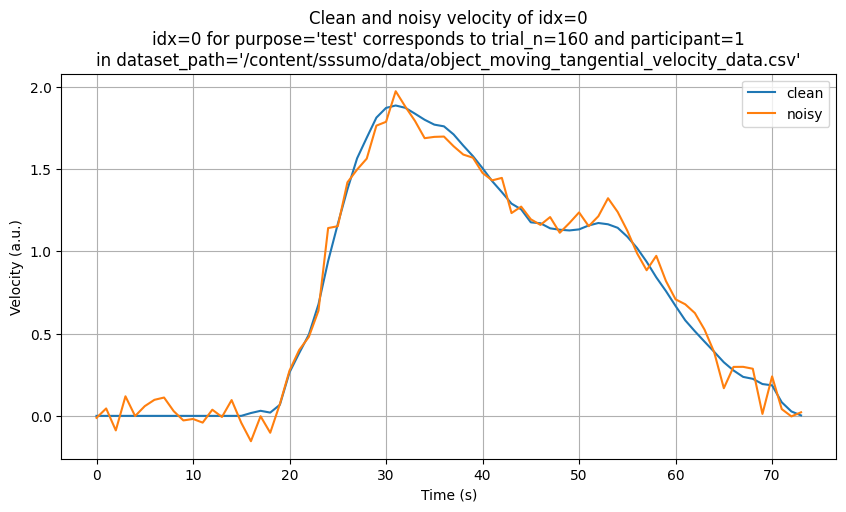

In [ ]:
purpose = 'test'

organic_dataset_kwargs = \
 {'snr_distribution': 20,
 'noise_mode': 'gaussian',
 'quadratic_mean': 1,
 'low_pass_filter': np.inf,
 'purpose': purpose}


dataset = OrganicDataset(dataset_path, **organic_dataset_kwargs)

idx = 0
trial_n = dataset.trials[idx]
participant = dataset.participants[idx].item()

noisy_vel, clean_vel, _ = dataset[idx]


print(f'{idx=} corresponds to {trial_n=} and {participant=} in {dataset_path=}')

plt.figure(figsize=(10, 5))
plt.plot(clean_vel[0], label='clean')
plt.plot(noisy_vel[0], label='noisy')
plt.grid()
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Velocity (a.u.)')

plt.title(f'Clean and noisy velocity of {idx=}\n'
f'{idx=} for {purpose=} corresponds to {trial_n=} and {participant=}\n'
f'in {dataset_path=}')

plt.show()



### Converting dataset with motion recorded in Cartesian coordinates (1D to 3D)

`dataset_reader.py` contains the code that is used to convert human motion datasets used in analysis to the structure needed for training. Function `df_to_tangential_velocity` is the entry point here.

1D movement signals such as steering or crank rotation can be used directly as soon as they are resampled at 60 samples per second and contain the required columns.
2D and 3D datasets need to be processed in order to obtain the signed tangential velocity signal.

Datasets suited for preprocessing using `df_to_tangential_velocity` should be .csv files that include columns `x`, `y`, `z` (arbitrary units, depending on the number of dimensions), `participant` (string or integer), `trial_n` (integer or string, should be unique, the same `trial_n` should not be repeated for different participants), `time` (in seconds). They will be resampled and `tangential_velocity` will be calculated.


